In [1]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 8.0 MB/s  0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [7]:
df = pd.read_csv(r"C:\Users\sahus\OneDrive\Desktop\Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [9]:
# Drop rows where Review Text is missing
df = df.dropna(subset=['Review Text'])

# Confirm
print(df.shape)

(22641, 11)


In [12]:
# Function to get sentiment
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

# Apply to every review
df['Sentiment'] = df['Review Text'].apply(get_sentiment)

# See results
df[['Review Text', 'Sentiment']].head(10)

,Review Text,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,Positive
1,Love this dress! it's sooo pretty. i happene...,Positive
2,I had such high hopes for this dress and reall...,Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",Positive
4,This shirt is very flattering to all due to th...,Positive
5,"I love tracy reese dresses, but this one is no...",Positive
6,I aded this in my basket at hte last mintue to...,Positive
7,"I ordered this in carbon for store pick up, an...",Positive
8,I love this dress. i usually get an xs but it ...,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",Positive


In [13]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    21227
Negative     1315
Neutral        99
Name: count, dtype: int64


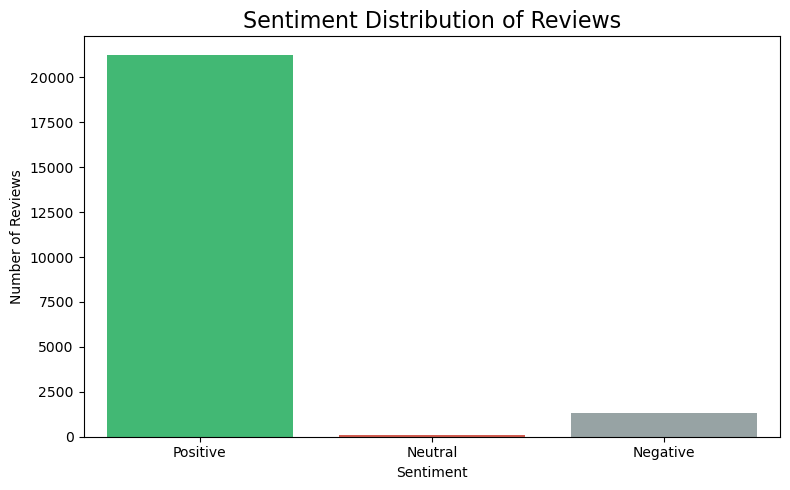

In [14]:
# Bar chart
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, 
              hue='Sentiment', legend=False,
              order=['Positive', 'Neutral', 'Negative'],
              palette=['#2ecc71', '#95a5a6', '#e74c3c'])
plt.title('Sentiment Distribution of Reviews', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

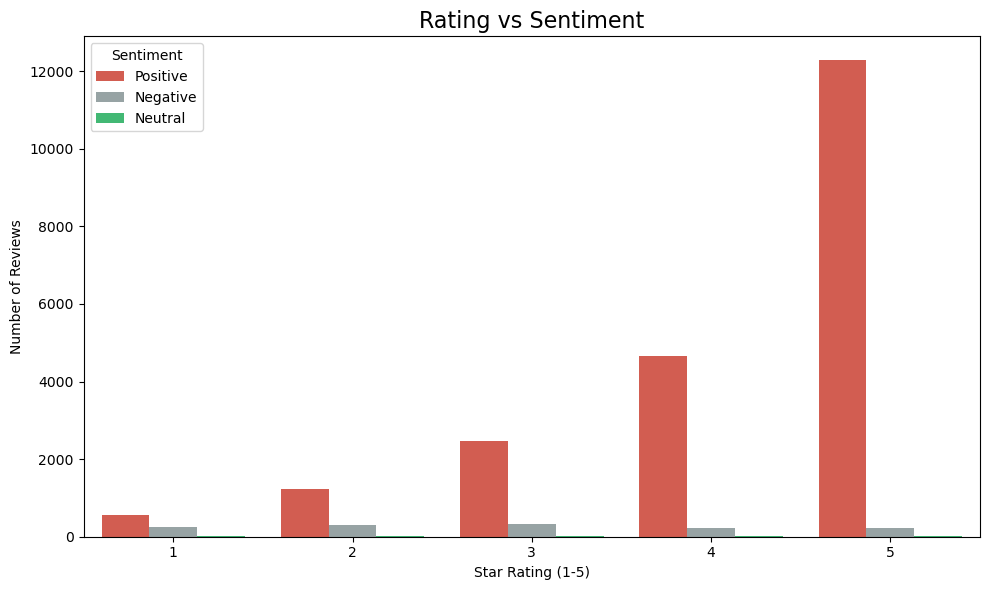

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', hue='Sentiment', data=df,
              palette=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Rating vs Sentiment', fontsize=16)
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Finding - Sentiment vs Rating
Interestingly, even 1 and 2 star reviews show mostly Positive sentiment.
This is because TextBlob analyzes individual words, not the overall context.
For example, a review saying "I loved the fabric but the sizing was terrible"
gets classified as Positive due to the word "loved".
This shows the limitation of basic sentiment analysis tools like TextBlob.

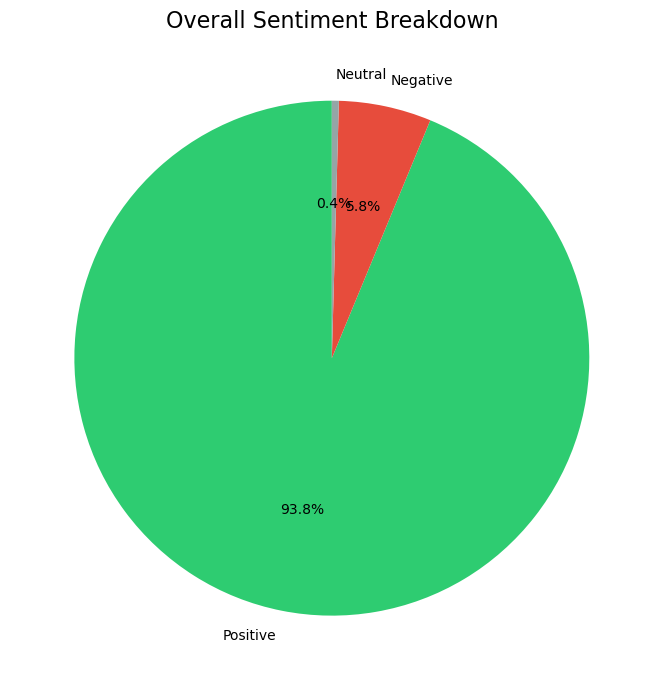

In [17]:
plt.figure(figsize=(7, 7))
sentiment_counts = df['Sentiment'].value_counts()
plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c', '#95a5a6'],
        startangle=90)
plt.title('Overall Sentiment Breakdown', fontsize=16)
plt.tight_layout()
plt.show()

    ## Overall Findings - Sentiment Analysis

1. 93.8% of reviews are Positive, showing high customer satisfaction.
2. Only 5.8% of reviews are Negative.
3. TextBlob works well for general sentiment but struggles with 
   mixed reviews — it picks up positive words even in low-rated reviews.
4. For better accuracy, advanced models like VADER or BERT 
   would be more suitable for real-world applications.